# Dataset Selection
The dataset we've chosen to use is the GoEmotions dataset from Google. It contains curated comments from Reddit with various metadata about each comment as well as annotations denoting an associated emotion. 

The dataset contains the following columns for each comment entry:
- comment text
- comment id
- author of the comment
- subreddit the comment was written in
- comment link id
- comment parent id
- comment post timestamp
- annotator's id
- if comment was difficult to label
- columns for each of the 27 emotion labels denoting true (1) or false (0)

The dataset can be found on GitHub here: https://github.com/google-research/google-research/tree/master/goemotions

The dataset is released by Google under the CC BY 4.0 International License that can be found here: https://creativecommons.org/licenses/by/4.0/legalcode

The repository requests that we cite the original paper that the dataset was created for:  
Demszky, D., Movshovitz-Attias, D., Ko, J., Cowen, A., Nemade, G., & Ravi, S. (2020). GoEmotions: A dataset of fine-grained emotions. In *58th Annual Meeting of the Association for Computational Linguistics (ACL)*.

# GoEmotions Dataset

In [12]:
import pandas as pd

base_url = "https://huggingface.co/datasets/google-research-datasets/go_emotions/resolve/main/simplified/"

train_df = pd.read_parquet(base_url + "train-00000-of-00001.parquet")
val_df = pd.read_parquet(base_url + "validation-00000-of-00001.parquet")
test_df = pd.read_parquet(base_url + "test-00000-of-00001.parquet")

train_df

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj
...,...,...,...
43405,Added you mate well I’ve just got the bow and ...,[18],edsb738
43406,Always thought that was funny but is it a refe...,[6],ee7fdou
43407,What are you talking about? Anything bad that ...,[3],efgbhks
43408,"More like a baptism, with sexy results!",[13],ed1naf8


## Preprocessing dataset


## Dataset Filtering and cleaning 

In [13]:
# check size of each dataset split
print(len(train_df), len(val_df), len(test_df))

# check for nulls/empty text 
print(train_df['text'].isnull().sum())
print((train_df['text'].str.strip() == '').sum())

# check for duplicate text across splits
train_texts = set(train_df['text'])
test_texts = set(test_df['text'])
print(len(train_texts & test_texts)) 

# check label distribution
print(train_df['labels'].explode().value_counts())

43410 5426 5427
0
0
32
labels
27    14219
0      4130
4      2939
15     2662
3      2470
1      2328
7      2191
18     2086
10     2022
20     1581
2      1567
17     1452
6      1368
25     1326
9      1269
22     1110
5      1087
26     1060
13      853
11      793
8       641
14      596
24      545
12      303
19      164
23      153
21      111
16       77
Name: count, dtype: int64


In [14]:

# Label and group mappings 
LABEL_NAMES = [
    "admiration","amusement","anger","annoyance","approval","caring",
    "confusion","curiosity","desire","disappointment","disapproval",
    "disgust","embarrassment","excitement","fear","gratitude","grief",
    "joy","love","nervousness","optimism","pride","realization","relief",
    "remorse","sadness","surprise","neutral"
]
# Map each label to its corresponding group
GROUP_MAP = {
    "admiration":"positive","amusement":"positive","approval":"positive",
    "caring":"positive","desire":"positive","excitement":"positive",
    "gratitude":"positive","joy":"positive","love":"positive",
    "optimism":"positive","pride":"positive","relief":"positive",
    "anger":"negative","annoyance":"negative","disappointment":"negative",
    "disapproval":"negative","disgust":"negative","embarrassment":"negative",
    "fear":"negative","grief":"negative","nervousness":"negative",
    "remorse":"negative","sadness":"negative",
    "confusion":"ambiguous","curiosity":"ambiguous",
    "realization":"ambiguous","surprise":"ambiguous",
    "neutral":"neutral"
}
# Function to convert label IDs to their corresponding groups
def labels_to_groups_all(label_ids):
    names = [LABEL_NAMES[i] for i in label_ids]
    groups = [GROUP_MAP[n] for n in names]
    return list(dict.fromkeys(groups))

# Process each dataset split
def process_split(df):
    df = df.copy()
    df["all_groups"] = df["labels"].apply(labels_to_groups_all)
    df["num_distinct_groups"] = df["all_groups"].apply(len)
    clean = df[df["num_distinct_groups"] == 1].copy()
    clean["group_label"] = clean["all_groups"].apply(lambda g: g[0])
    conflict = df[df["num_distinct_groups"] > 1].copy()
    return clean, conflict

# Process all dataset splits
train_clean, train_conflict = process_split(train_df)
val_clean, val_conflict = process_split(val_df)
test_clean, test_conflict = process_split(test_df)

In [15]:
# Display statistics for each dataset split
print(f"Train: {len(train_clean)} clean / {len(train_conflict)} conflicting "
      f"({len(train_conflict)/len(train_df)*100:.1f}%)")
print(f"Val:   {len(val_clean)} clean / {len(val_conflict)} conflicting "
      f"({len(val_conflict)/len(val_df)*100:.1f}%)")
print(f"Test:  {len(test_clean)} clean / {len(test_conflict)} conflicting "
      f"({len(test_conflict)/len(test_df)*100:.1f}%)")

# Display label distribution for the clean datasets
print(train_clean["group_label"].value_counts())
print(val_clean["group_label"].value_counts())
print(test_clean["group_label"].value_counts())

Train: 40030 clean / 3380 conflicting (7.8%)
Val:   5006 clean / 420 conflicting (7.7%)
Test:  5027 clean / 400 conflicting (7.4%)
group_label
positive     15216
neutral      12823
negative      8133
ambiguous     3858
Name: count, dtype: int64
group_label
positive     1941
neutral      1592
negative     1014
ambiguous     459
Name: count, dtype: int64
group_label
positive     1863
neutral      1606
negative     1070
ambiguous     488
Name: count, dtype: int64


In [16]:
# Count how many rows in the training set have more than one label
multi_label_count = (train_df["labels"].apply(len) > 1).sum()
print(multi_label_count, "of", len(train_df), "rows have more than one label")
print(multi_label_count / len(train_df) * 100, "%")

7102 of 43410 rows have more than one label
16.360285648468096 %


## Data Visualization

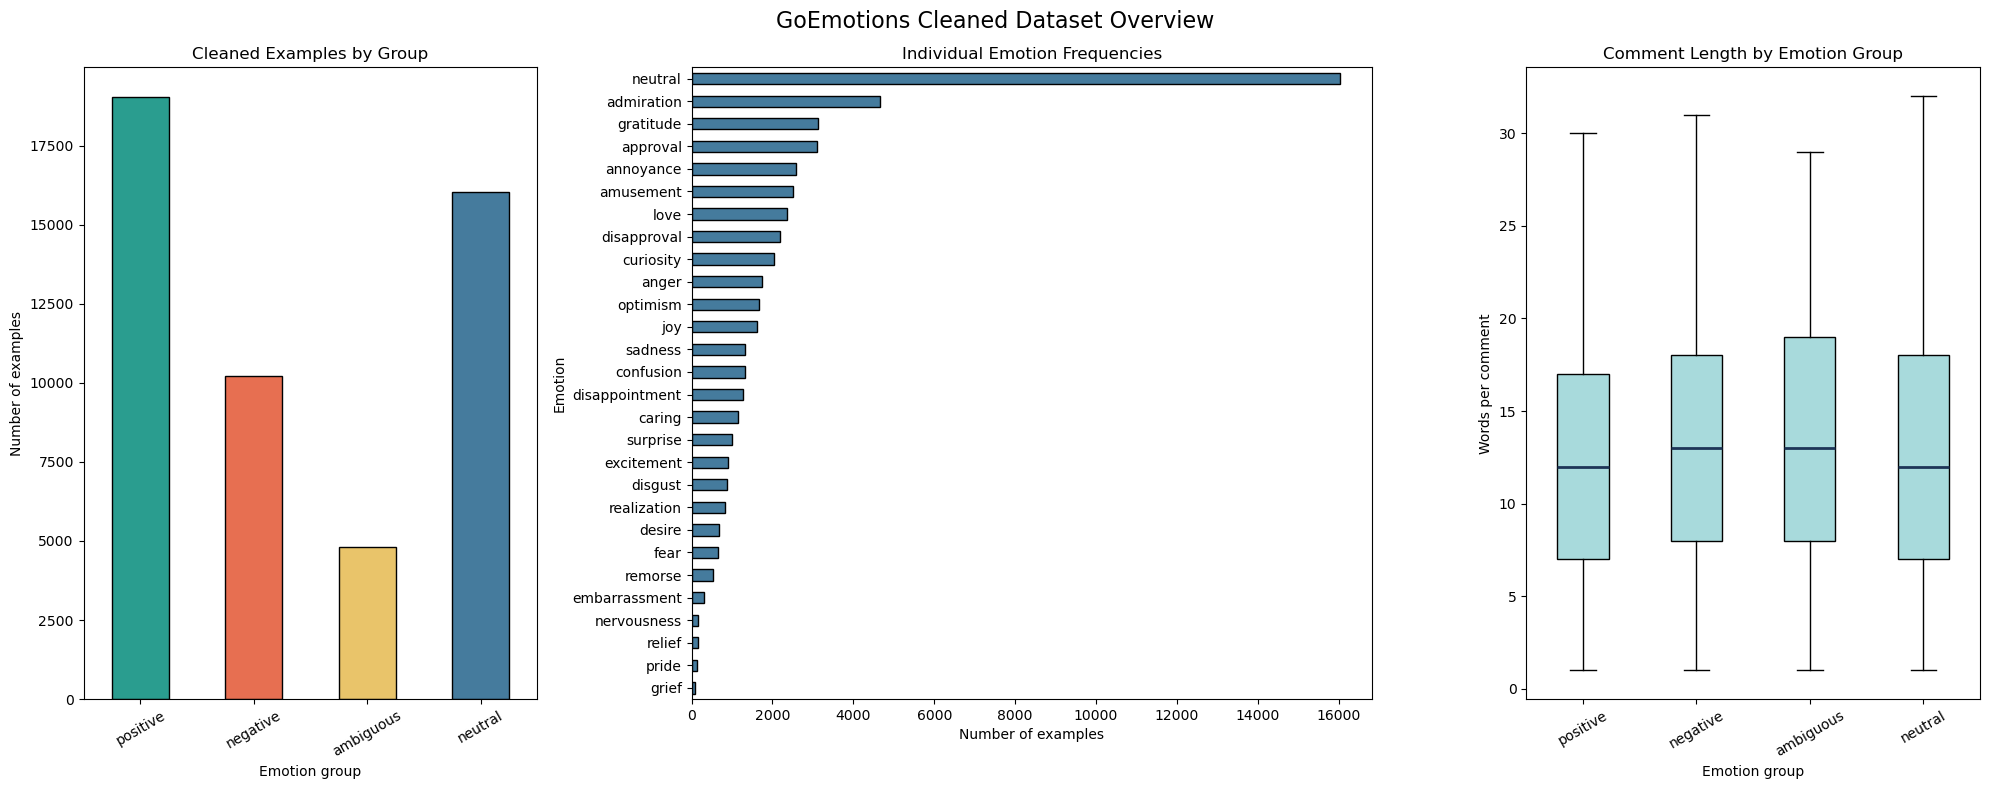

In [17]:
import matplotlib.pyplot as plt

# Combine the cleaned datasets for visualization.
cleaned_data = pd.concat([train_clean, val_clean, test_clean], ignore_index=True)

group_order = ["positive", "negative", "ambiguous", "neutral"]
group_colors = ["#2a9d8f", "#e76f51", "#e9c46a", "#457b9d"]

# Prepare counts for the bar plots.
all_group_counts = cleaned_data["group_label"].value_counts().reindex(group_order, fill_value=0)
emotion_counts = (
    cleaned_data["labels"]
    .explode()
    .map(lambda label_id: LABEL_NAMES[label_id])
    .value_counts()
    .reindex(LABEL_NAMES, fill_value=0)
    .sort_values()
)

# Calculate word counts for the boxplot.
word_counts_by_group = [
    cleaned_data.loc[cleaned_data["group_label"] == group, "text"]
    .fillna("")
    .str.split()
    .str.len()
    .tolist()
    for group in group_order
]

fig, axes = plt.subplots(1, 3, figsize=(20, 8), gridspec_kw={"width_ratios": [1, 1.5, 1]})

all_group_counts.plot.bar(ax=axes[0], color=group_colors, edgecolor="black")
axes[0].set_title("Cleaned Examples by Group")
axes[0].set_xlabel("Emotion group")
axes[0].set_ylabel("Number of examples")
axes[0].tick_params(axis="x", rotation=30)

emotion_counts.plot.barh(ax=axes[1], color="#457b9d", edgecolor="black")
axes[1].set_title("Individual Emotion Frequencies")
axes[1].set_xlabel("Number of examples")
axes[1].set_ylabel("Emotion")

axes[2].boxplot(word_counts_by_group, tick_labels=group_order, patch_artist=True,
                boxprops={"facecolor": "#a8dadc"},
                medianprops={"color": "#1d3557", "linewidth": 2})
axes[2].set_title("Comment Length by Emotion Group")
axes[2].set_xlabel("Emotion group")
axes[2].set_ylabel("Words per comment")
axes[2].tick_params(axis="x", rotation=30)

fig.suptitle("GoEmotions Cleaned Dataset Overview", fontsize=16)
fig.tight_layout()
plt.show()

# print("Combined rows:", len(cleaned_data))
# print("Original columns:", list(cleaned_data.columns))
# print("Group counts:")
# print(all_group_counts)
# print("Individual emotion counts:")
# print(emotion_counts.sort_values(ascending=False))

### Visualization explanations and observations

- **Cleaned examples by group:** This bar chart shows the total number of cleaned comments assigned to each broad emotion group. Positive is the largest broad group with 19,020 examples, followed by neutral with 16,021, negative with 10,217, and ambiguous with 4,805.

- **Individual emotion frequencies:** This horizontal bar chart shows the frequency of each of the 28 original emotion labels. Neutral is the most frequent individual label with 16,021 examples, followed by admiration with 4,648. Grief is the least frequent label with only 81 examples, showing substantial imbalance among the individual emotions.

- **Comment length by emotion group:** This boxplot compares the number of words per comment for each broad group. The median lengths are similar, ranging from about 12 to 13 words, while the boxes and whiskers show broadly comparable distributions. Neutral comments have the highest upper whisker at about 32 words, indicating some longer comments in that group.

Together, the visualizations show that the dataset is unevenly distributed across emotion labels, especially for rare emotions such as grief, pride, relief, and nervousness. Comment length is more consistent across the four broad groups than label frequency.